Simulated Annealing Plots

In [194]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [195]:
# Parameters
results_path = 'data/simulated_annealing/summary_2026-04-08_15-05-55.npy'
brute_force_data_directory = './data/brute_force/test' # use same as in cl_optimizer_experiments

In [196]:
import numpy as np

result_tensor = np.load(results_path)

In [197]:
result_tensor.shape # should be a 5-tuple: (n_problem_sizes, n_instances_per_problem_size, n_runs_per_instance, n_temp_iter_steps, 3)

(20, 4, 2, 11, 3)

In [198]:
loss_tensor = result_tensor[:, :, :, :, 2]
temp_iterations = result_tensor[0, 0, 0, :, 1]

In [199]:
from pathlib import Path
import numpy as np
import pandas as pd
import re

data_files = [p for p in Path(brute_force_data_directory).glob("*.csv") if p.is_file()]
candidate_dims = [(np.log2(int(re.search(string=str(p.name), pattern=r'_(\d*)_(candidates|instances)').group(1))), p) for p in data_files]

df = pd.DataFrame(data=candidate_dims, columns=['dims','paths'])
df = df.groupby('dims')['paths'].agg(list).reset_index()

In [200]:
problem_sizes = df['dims'].tolist()
brute_force_data_paths = df['paths'].tolist()
boundss = df['dims'].apply(lambda x: int(x) * [(0, 1)]).tolist()

In [201]:
import pandas as pd
import numpy as np

brute_force_data = [[pd.read_csv(p) for p in path] for path in brute_force_data_paths]
loss_spaces = [np.array([d['loss'] for d in data]) for data in brute_force_data]

In [202]:
from metrics import raar

avg_loss_runs = loss_tensor.mean(axis=2)
raars = np.array([[[raar(avg, loss_spaces[i][j, :]) for avg in avg_loss] for j, avg_loss in enumerate(avg_loss_runs_per_problem_size)] for i, avg_loss_runs_per_problem_size in enumerate(avg_loss_runs)])
mean_raar = raars.mean(axis=(0, 1))
std_raar = raars.std(axis=(0, 1))

<Axes: xlabel='Temperature Iterations', ylabel='RAAR'>

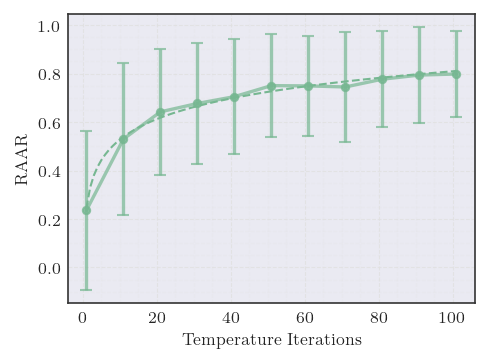

In [203]:
import styling
import matplotlib.pyplot as plt
import seaborn as sns

styling.set_my_style()

df = pd.DataFrame()
df["Temperature Iterations"] = temp_iterations
df["RAAR"] = mean_raar.squeeze()
df["RAAR_std"] = std_raar.squeeze()

palette = styling.shades(6, 4)[1:]
palette = sns.color_palette("crest", 5)


fig, ax = styling.subplots(figsize=(3.5, 2.5))

plt.plot(
    df["Temperature Iterations"],
    df["RAAR"],
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)


ax.errorbar(
    x=df["Temperature Iterations"],
    y=df["RAAR"],
    yerr=df["RAAR_std"],
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)

sns.regplot(x=df["Temperature Iterations"], y=df["RAAR"], color=palette[0], ax=ax, line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)

In [204]:
min_losses = np.array([spaces.min(axis=1) for spaces in loss_spaces])
min_loss_candidates = np.array([[d[d['loss'] == m]['candidate'] for d, m in zip(data, min_loss)] for data, min_loss in zip(brute_force_data, min_losses)]).squeeze()

In [205]:
optimal_candidates_found = np.count_nonzero(loss_tensor ==  min_losses.reshape(min_losses.shape[0], min_losses.shape[1], 1, 1), axis=2)
p_star = (optimal_candidates_found.T / loss_tensor.shape[-1]).T

In [206]:
from metrics import tts_p
tts_ps = np.apply_along_axis(tts_p, axis=-1, arr=p_star)

mask = np.any(np.isfinite(tts_ps), axis=(0, 1))
non_inf_tts_ps = tts_ps[..., mask] # filter np.inf values

In [207]:
# TTS(p) | Temperature Iterations (p)
finite_mask = np.any(np.isfinite(non_inf_tts_ps), axis=-1, keepdims=True)

masked = np.ma.masked_invalid(non_inf_tts_ps)
mean_tts_ps = masked.mean(axis=(0, 1)).data
std_tts_ps = masked.std(axis=(0, 1)).data

In [208]:
# TTS* | Problem Size N
masked = np.ma.masked_invalid(non_inf_tts_ps)
min_tts = masked.min(axis=-1).squeeze().data
avg_min_tts = min_tts.mean(axis=-1)
std_min_tts = min_tts.std(axis=-1)

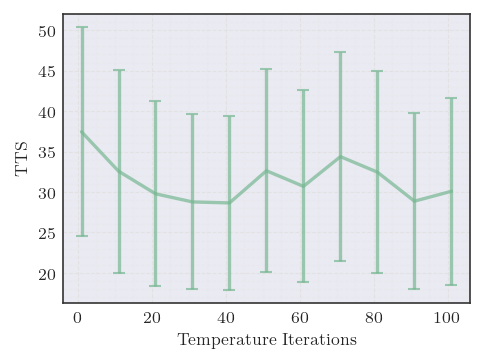

In [209]:
from matplotlib import pyplot as plt

fig, ax = styling.subplots(figsize=(3.5, 2.5))

ax.plot(
    temp_iterations[mask],
    mean_tts_ps,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

ax.errorbar(
    temp_iterations[mask],
    y=mean_tts_ps,
    yerr=std_tts_ps,
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)
plt.ylabel('TTS')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)

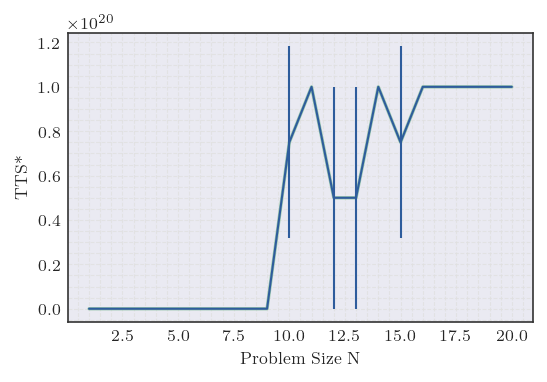

In [210]:
plt.plot(
    problem_sizes,
    avg_min_tts,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

plt.errorbar(
    problem_sizes,
    y=avg_min_tts,
    yerr=std_min_tts,
)
plt.ylabel('TTS*')
plt.xlabel('Problem Size N')
plt.grid(visible=True)